# Predicting the Sale Price of Bulldozers using Machine Learning

This notebook explores the use of Python-based machine learning and data science tools to build a regression model capable of predicting the auction sale price of bulldozers based on historical sales data, machine specifications, and auction information.

The project demonstrates a complete supervised machine learning workflow, including data preparation, feature engineering, model training, hyperparameter tuning, and model evaluation.

We're going to take the following approach:

- Problem Definition
- Data
- Evaluation
- Features
- Modelling
- Experimentation

## 1. Problem Definition
Given historical auction data and machine characteristics, can we accurately predict the future sale price of a bulldozer?

This is a supervised regression problem where the target variable is the sale price of a machine.

## 2. Data
The dataset comes from the Blue Book for [Bulldozers Kaggle competition.](https://www.kaggle.com/c/bluebook-for-bulldozers/data)

The data contains historical sales records of bulldozers sold at auctions, along with machine attributes, usage information, product categories, and sale dates.

The dataset includes:

* Training data containing historical auction results and sale prices, which contains data through the end of 2011.
* Validation data used to evaluate model performance on unseen examples, which contains data from January 1, 2012 - April 30, 2012.
* Test data for generating final predictions, which contains data from May 1, 2012 - November 2012.

## 3. Evaluation
The competition uses Root Mean Squared Log Error (RMSLE) as the primary evaluation metric.

RMSLE is particularly suitable because auction prices can vary significantly between machines, and percentage-based prediction errors are generally more meaningful than absolute dollar differences.

The objective of this project is to build a model that minimizes RMSLE while maintaining strong generalization performance on unseen data.

[More on the evaluation of this project check.](https://www.kaggle.com/c/bluebook-for-bulldozers/overview/evaluation)

## 4. Features
The dataset contains a mixture of:

* Machine specifications
* Product categories
* Usage information
* Equipment configuration details
* Auction metadata
* Time-based information derived from sale dates

Kaggle provides [a data dictionary](https://docs.google.com/spreadsheets/d/18ly-bLR8sbDJLITkWG7ozKm8l3RyieQ2Fpgix-beSYI/edit?usp=sharing) detailing all of the features of the dataset.

Several additional date-related features will be engineered during preprocessing, including:
* Sale year
* Sale month
* Sale day
* Sale day of week
* Sale day of year

These features help the model capture seasonal and long-term trends in equipment pricing.

## Preparing the tools

In [1]:
# Imports

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
%matplotlib inline

# Machine Learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_log_error,
    mean_absolute_error,
    r2_score
)
from sklearn.model_selection import RandomizedSearchCV

## Loading data

In [2]:
# Import training and validation sets
df = pd.read_csv("data/TrainAndValid.csv", low_memory=False)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   SalesID                   412698 non-null  int64  
 1   SalePrice                 412698 non-null  float64
 2   MachineID                 412698 non-null  int64  
 3   ModelID                   412698 non-null  int64  
 4   datasource                412698 non-null  int64  
 5   auctioneerID              392562 non-null  float64
 6   YearMade                  412698 non-null  int64  
 7   MachineHoursCurrentMeter  147504 non-null  float64
 8   UsageBand                 73670 non-null   str    
 9   saledate                  412698 non-null  str    
 10  fiModelDesc               412698 non-null  str    
 11  fiBaseModel               412698 non-null  str    
 12  fiSecondaryDesc           271971 non-null  str    
 13  fiModelSeries             58667 non-null   str    
 14 

In [4]:
df.isna().sum()

SalesID                          0
SalePrice                        0
MachineID                        0
ModelID                          0
datasource                       0
auctioneerID                 20136
YearMade                         0
MachineHoursCurrentMeter    265194
UsageBand                   339028
saledate                         0
fiModelDesc                      0
fiBaseModel                      0
fiSecondaryDesc             140727
fiModelSeries               354031
fiModelDescriptor           337882
ProductSize                 216605
fiProductClassDesc               0
state                            0
ProductGroup                     0
ProductGroupDesc                 0
Drive_System                305611
Enclosure                      334
Forks                       214983
Pad_Type                    331602
Ride_Control                259970
Stick                       331602
Transmission                224691
Turbocharged                331602
Blade_Extension     

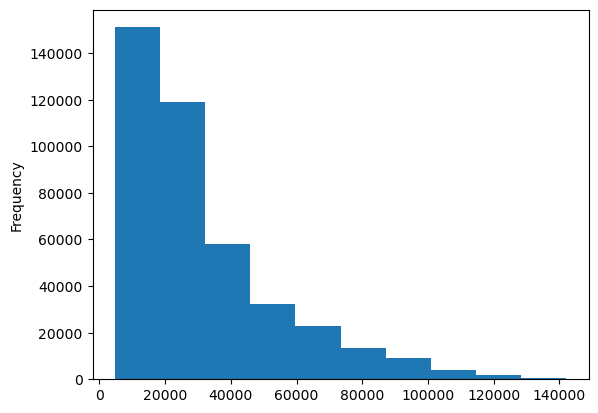

In [6]:
df.SalePrice.plot.hist();

In [7]:
df.saledate.dtype

<StringDtype(storage='python', na_value=nan)>

In [8]:
df["SalePrice"].describe()

count    412698.000000
mean      31215.181414
std       23141.743695
min        4750.000000
25%       14500.000000
50%       24000.000000
75%       40000.000000
max      142000.000000
Name: SalePrice, dtype: float64

The sale price ranges from 4,750 to 142,000, with a median sale price of 24,000 and an average sale price of approximately 31,215.
The histogram shows that most bulldozers are sold at lower price ranges, while a smaller number of machines are sold at significantly higher prices.

### Initial Dataset Inspection

The dataset contains 412,698 historical bulldozer auction records and 53 features describing machine specifications, product categories, auction metadata, and sale information.

Initial inspection reveals several important characteristics:

- The dataset contains a mixture of numerical and string features.
- Many columns contain missing values, which will require preprocessing before model training.
- Several machine configuration attributes are sparsely populated, suggesting that not every machine includes all available equipment options.
- The target variable (`SalePrice`) is right-skewed, indicating that most bulldozers are sold at lower prices while a smaller number of machines are sold at significantly higher prices.
- The `saledate` column is currently stored as a string and will need to be converted into a datetime format to enable time-based feature engineering.

### Parsing dates

The `saledate` column is loaded as a string (`object`) data type.

Since sale date is likely to contain valuable temporal information, we convert it into a datetime format before further feature engineering.

In [9]:
# Reload dataset and parse the sale date column as datetime
df = pd.read_csv(
    "data/TrainAndValid.csv",
    low_memory=False,
    parse_dates=["saledate"]
)

In [10]:
df.saledate.dtype

dtype('<M8[us]')

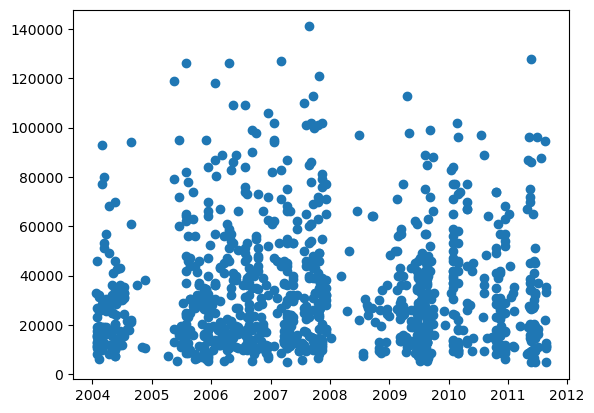

In [11]:
fig, ax =plt.subplots()
ax.scatter(df["saledate"][:1000],df["SalePrice"][:1000]);

In [18]:
df.head()
#df.head().T # using T to make the all columns visible

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1139246,66000.0,999089,3157,121,3.0,2004,68.0,Low,2006-11-16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139248,57000.0,117657,77,121,3.0,1996,4640.0,Low,2004-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
2,1139249,10000.0,434808,7009,121,3.0,2001,2838.0,High,2004-02-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1139251,38500.0,1026470,332,121,3.0,2001,3486.0,High,2011-05-19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139253,11000.0,1057373,17311,121,3.0,2007,722.0,Medium,2009-07-23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Sort Dataset by Sale Date

Since this project involves historical auction data, sorting the orders chronologically before performing any time-based analysis or validation.

In [22]:
# Sort DataFrame in date order
df.sort_values(by=["saledate"], inplace=True, ascending=True)

In [31]:
# Make a copy of the original DataFrame to perform edits on
df_processed = df.copy()

### Feature Engineering

Raw datetime values are often difficult for machine learning algorithms to use directly.

To help the model capture seasonal patterns and long-term market trends, several features are extracted from the `saledate` column.
- Sale year
- Sale month
- Sale day
- Day of week
- Day of year

These derived features may help the model identify recurring patterns in bulldozer pricing over time.

In [32]:
df_processed["saleYear"] = df_processed.saledate.dt.year
df_processed["saleMonth"] = df_processed.saledate.dt.month
df_processed["saleDay"] = df_processed.saledate.dt.day
df_processed["saleDayOfWeek"] = df_processed.saledate.dt.dayofweek
df_processed["saleDayOfYear"] = df_processed.saledate.dt.dayofyear

After extracting the relevant temporal information, the original `saledate` column is no longer required.

Keeping both the raw datetime column and its derived features may introduce redundant information, so the original column is removed.

In [33]:
df_processed.drop("saledate", axis=1, inplace=True)

## Data Preprocessing

Before training a model, the dataset must be transformed into a suitable format suitable.

The dataset contains:

- Missing values across multiple features
- Categorical variables stored as strings

In this section, we will inspect the data, convert categorical features, handle missing values, and prepare the dataset for machine learning.

### Inspecting Data Types and Missing Values

In [34]:
df_processed.info()

<class 'pandas.DataFrame'>
Index: 412698 entries, 205615 to 409203
Data columns (total 57 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   SalesID                   412698 non-null  int64  
 1   SalePrice                 412698 non-null  float64
 2   MachineID                 412698 non-null  int64  
 3   ModelID                   412698 non-null  int64  
 4   datasource                412698 non-null  int64  
 5   auctioneerID              392562 non-null  float64
 6   YearMade                  412698 non-null  int64  
 7   MachineHoursCurrentMeter  147504 non-null  float64
 8   UsageBand                 73670 non-null   str    
 9   fiModelDesc               412698 non-null  str    
 10  fiBaseModel               412698 non-null  str    
 11  fiSecondaryDesc           271971 non-null  str    
 12  fiModelSeries             58667 non-null   str    
 13  fiModelDescriptor         74816 non-null   str    
 14 

In [35]:
df_processed.isna().sum()

SalesID                          0
SalePrice                        0
MachineID                        0
ModelID                          0
datasource                       0
auctioneerID                 20136
YearMade                         0
MachineHoursCurrentMeter    265194
UsageBand                   339028
fiModelDesc                      0
fiBaseModel                      0
fiSecondaryDesc             140727
fiModelSeries               354031
fiModelDescriptor           337882
ProductSize                 216605
fiProductClassDesc               0
state                            0
ProductGroup                     0
ProductGroupDesc                 0
Drive_System                305611
Enclosure                      334
Forks                       214983
Pad_Type                    331602
Ride_Control                259970
Stick                       331602
Transmission                224691
Turbocharged                331602
Blade_Extension             386715
Blade_Width         

### Convert string to categories
As an intermediate step, string-based features will be converted into ordered categorical data types. This allows us to inspect category values while preparing the dataset for numerical encoding later in the workflow.

In [39]:
for label, content in df_processed.items():
    if pd.api.types.is_string_dtype(content):
        df_processed[label] = content.astype("category").cat.as_ordered()

In [40]:
df_processed.info()

<class 'pandas.DataFrame'>
Index: 412698 entries, 205615 to 409203
Data columns (total 57 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   SalesID                   412698 non-null  int64   
 1   SalePrice                 412698 non-null  float64 
 2   MachineID                 412698 non-null  int64   
 3   ModelID                   412698 non-null  int64   
 4   datasource                412698 non-null  int64   
 5   auctioneerID              392562 non-null  float64 
 6   YearMade                  412698 non-null  int64   
 7   MachineHoursCurrentMeter  147504 non-null  float64 
 8   UsageBand                 73670 non-null   category
 9   fiModelDesc               412698 non-null  category
 10  fiBaseModel               412698 non-null  category
 11  fiSecondaryDesc           271971 non-null  category
 12  fiModelSeries             58667 non-null   category
 13  fiModelDescriptor         74816 non-null

All string values were converted into categories.

In [42]:
# Analyzing missing data
missing_pct = (df_processed.isnull().sum() / len(df_processed)).sort_values(ascending=False)

missing_pct.head(15)

Blade_Width          0.937041
Enclosure_Type       0.937041
Engine_Horsepower    0.937041
Tip_Control          0.937041
Pushblock            0.937041
Blade_Extension      0.937041
Scarifier            0.937014
Grouser_Tracks       0.891264
Hydraulics_Flow      0.891264
Coupler_System       0.891024
fiModelSeries        0.857845
Steering_Controls    0.826697
Differential_Type    0.826595
UsageBand            0.821492
fiModelDescriptor    0.818715
dtype: float64

### Handling missing values

#### Filling numerical missing values

In [51]:
numeric_missing = (
    df_processed.select_dtypes(include=["number"])
    .isnull()
    .sum()
)

numeric_missing[numeric_missing > 0]

Series([], dtype: int64)

In [52]:
# Fill numeric columns with median
for label, content in df_processed.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            # Add a binary column which tells us if the data was missing or not
            df_processed[label+"_is_missing"] = pd.isnull(content)
            # Fill missing numeric values with median
            df_processed[label] = content.fillna(content.median())

In [53]:
df_processed.isna().sum()

SalesID                                     0
SalePrice                                   0
MachineID                                   0
ModelID                                     0
datasource                                  0
auctioneerID                                0
YearMade                                    0
MachineHoursCurrentMeter                    0
UsageBand                              339028
fiModelDesc                                 0
fiBaseModel                                 0
fiSecondaryDesc                        140727
fiModelSeries                          354031
fiModelDescriptor                      337882
ProductSize                            216605
fiProductClassDesc                          0
state                                       0
ProductGroup                                0
ProductGroupDesc                            0
Drive_System                           305611
Enclosure                                 334
Forks                             

#### Filling and turning categorical variables into numbers
Most machine learning algorithms require numerical input and cannot directly process categorical values stored as text.

Earlier, string features were converted to Pandas categorical data types. In this step, these categories are converted into numerical representations that can be used by the model.

For categorical features containing missing values, an additional binary indicator column is created to preserve information about whether the original value was missing.

This approach ensures that:

* All features become numeric.
* Missing categorical values are retained as potentially useful information.
* The dataset is compatible with machine learning algorithms such as Random Forest. 

In [54]:
# Turn categorical variables into numbers and fill missing
for label, content in df_processed.items():
    if not pd.api.types.is_numeric_dtype(content):
        # Add binary column to indicate whether sample had missing value
        df_processed[label+"_is_missing"] = pd.isnull(content)
        # Turn categories into numbers and add +1
        df_processed[label] = pd.Categorical(content).codes+1

In [55]:
df_processed.info()

<class 'pandas.DataFrame'>
Index: 412698 entries, 205615 to 409203
Columns: 103 entries, SalesID to Steering_Controls_is_missing
dtypes: bool(46), float64(3), int16(4), int32(5), int64(5), int8(40)
memory usage: 73.2 MB


In [56]:
df_processed.isna().sum()

SalesID                         0
SalePrice                       0
MachineID                       0
ModelID                         0
datasource                      0
                               ..
Backhoe_Mounting_is_missing     0
Blade_Type_is_missing           0
Travel_Controls_is_missing      0
Differential_Type_is_missing    0
Steering_Controls_is_missing    0
Length: 103, dtype: int64

In [58]:
print(f"Dataset shape after preprocessing: {df_processed.shape}")

Dataset shape after preprocessing: (412698, 103)


### Persisting the Processed Dataset

After preprocessing, the transformed dataset is saved to disk.

Persisting intermediate datasets improves reproducibility, reduces processing time during experimentation, and mirrors how data preparation and model training are typically separated in production machine learning workflows.

In [59]:
# Saving processed dataset
df_processed.to_csv(
    "data/TrainAndValid_processed.csv",
    index=False
)

### Final Preprocessing Check

At this stage, all features have been converted into numerical representations and missing values have been handled.

The dataset is now fully compatible with machine learning algorithms and ready for model training and evaluation.

## Dataset Ready for Machine Learning

After preprocessing:

- Missing numerical values have been imputed.
- Missing categorical values have been encoded.
- Additional date-based features have been engineered.
- All features have been converted to numerical representations.

The dataset now contains 103 machine-learning-ready features and no missing values.

The next step is to split the data into training and validation sets and train a model.

## 5. Modelling

In [62]:
#Reloading saved preprocessed dataset
df_processed = pd.read_csv(
    "data/TrainAndValid_processed.csv",
    low_memory=False
)

### Train / Validation Split

Before training a model, we divide dataset into training and validation sets using a time-based split.
According to the task:
* Training set contains data through the end of 2011.
* Validation set contains data from January 1, 2012 - April 30, 2012.

This prevents information from future sales leaking into the training process and provides a more realistic estimate of model performance on unseen data.

In [64]:
df_train = df_processed[df_processed.saleYear != 2012]
df_val = df_processed[df_processed.saleYear == 2012]

### Split data in X and y.
X_train, y_train = df_train.drop("SalePrice", axis=1), df_train["SalePrice"]
X_valid, y_valid = df_val.drop("SalePrice", axis=1), df_val["SalePrice"]

### Building an evaluation function

In [67]:
# Create evaluation function (according to the task the competition uses RMSLE)

def rmsle(y_true, y_pred):
    """
    Calculate Root Mean Squared Logarithmic Error (RMSLE) according to Kaggle task requirements.

    Args:
        y_true: Ground truth target values.
        y_pred: Predicted target values.

    Returns:
        float: RMSLE score between true and predicted values.
        """
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

# Create a function to evaluate model on a few different levels
def show_scores(model):
    """
    Evaluate model performance on training and validation datasets.

    Computes the primary regression metrics used throughout the project,
    allowing comparison between training and validation performance.

    Args:
        model: Trained sklearn regression model.

    Returns:
        dict[str, float]: Dictionary containing MAE, RMSLE, and R² metrics for both training and validation datasets.
    """
    train_preds = model.predict(X_train)
    val_preds = model.predict(X_valid)

    scores = {
        "Training MAE": mean_absolute_error(y_train, train_preds),
        "Valid MAE": mean_absolute_error(y_valid, val_preds),
        "Training RMSLE": rmsle(y_train, train_preds),
        "Valid RMSLE": rmsle(y_valid, val_preds),
        "Training R²": r2_score(y_train, train_preds),
        "Valid R²": r2_score(y_valid, val_preds),
    }

    return scores

### Baseline Model

Training a Random Forest on the full dataset (400K+ rows) is expensive during experimentation.

To accelerate development and hyperparameter tuning, an initial baseline model is trained using a subset of the available training data.

This allows faster iteration while still providing a reasonable estimate of model performance before training the final model on the complete dataset.

In [68]:
model = RandomForestRegressor(n_jobs=-1,
                              random_state=42,
                              max_samples=10000)

In [69]:
%%time
# Cutting down on the max number of samples each estimator can see improves training time
model.fit(X_train, y_train)

CPU times: total: 57.4 s
Wall time: 8.96 s


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [98]:
baseline_scores = pd.DataFrame(show_scores(model),index=["Score"]).T

baseline_scores

,Score
Training MAE,5554.733647
Valid MAE,7144.281229
Training RMSLE,0.257472
Valid RMSLE,0.293071
Training R²,0.860947
Valid R²,0.833336


### Baseline Results

The baseline Random Forest model was trained using a subset of the available training data to reduce experimentation time.

Validation performance:

| Metric | Score |
|---------|---------:|
| MAE | 7,144 |
| RMSLE | 0.293 |
| R² | 0.833 |

The relatively small gap between training and validation metrics suggests that the model generalizes reasonably well and is not severely overfitting.

General regression model performance is measured by R² scored 83.3%, which is good high starting point.

These results establish a baseline for evaluating improvements obtained through hyperparameter tuning.

## Hyperparameter Tuning with RandomizedSearchCV

The baseline model provides a reference point, but Random Forest performance depends heavily on hyperparameters.

For this project, tuning is performed on a reduced sample size (`max_samples=10000`) to keep experimentation time reasonable.
In a production environment, a broader search space and a larger number of iterations would likely be explored.

### Defining the Hyperparameter Search Space

The hyperparameter ranges were selected based on the characteristics of the dataset and practical experimentation constraints.

Key considerations:

*  The dataset contains more than 400,000 auction records and over 100 features, allowing the model to support larger forests (`n_estimators`) and deeper trees (`max_depth`).
* Smaller values of `min_samples_split` and `min_samples_leaf` were included to allow the model to capture complex relationships between machine attributes and sale price.
* `max_features` values were chosen to increase tree diversity, which is a core strength of Random Forest models.
* `max_samples` was limited to 10,000 observations per tree to reduce training time and accelerate experimentation.
* RandomizedSearchCV was chosen instead of GridSearchCV to efficiently explore the search space while keeping computational cost reasonable.

In [76]:
%%time

# Different RandomForestRegressor hyperparameters
rf_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", 0.3, 0.5, 0.7],
    "max_samples": [10000]}

# Instantiate RandomizedSearchCV model
random_search_model = RandomizedSearchCV(RandomForestRegressor(n_jobs=-1,
                                                    random_state=42),
                              param_distributions=rf_grid,
                              n_iter=50,
                              cv=5,
                              verbose=True)

# Fit the RandomizedSearchCV model
random_search_model.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
CPU times: total: 3h 3min
Wall time: 28min 34s


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 0.3, ...], 'max_samples': [10000], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... ver

#### Runtime Considerations

Increasing the number of iterations from initially set 10 to 50 improved the exploration of the hyperparameter search space, but also increased training time to approximately 29 minutes

In [84]:
best_parameters = pd.DataFrame(random_search_model.best_params_, index = ["Values"])
best_parameters

,n_estimators,min_samples_split,min_samples_leaf,max_samples,max_features,max_depth
Values,200,2,1,10000,0.7,30


In [97]:
# Checking the results of the baseline model along with the tuned model
tuned_model_scores = pd.DataFrame(show_scores(random_search_model),index=["Score"]).T

model_comparison = pd.concat(
    [
        baseline_scores.rename(columns={"Score": "Baseline"}),
        tuned_model_scores.rename(columns={"Score": "Tuned"})
    ],
    axis=1
)

model_comparison

,Baseline,Tuned
Training MAE,5554.733647,5596.509868
Valid MAE,7144.281229,7086.758029
Training RMSLE,0.257472,0.258930
Valid RMSLE,0.293071,0.292191
Training R²,0.860947,0.860153
Valid R²,0.833336,0.839202


### Hyperparameter Tuning Results

The tuned model achieved slight but consistent improvements across all validation metrics.

| Metric | Baseline | Tuned |
|---------|---------:|---------:|
| MAE | 7144 | 7087 |
| RMSLE | 0.293 | 0.292 |
| R² | 0.833 | 0.839 |

While the gains are relatively small, the results demonstrate that the selected hyperparameters improve the model's ability to generalize to unseen auction data.

The best-performing configuration favored:
- A larger forest (`n_estimators=200`)
- Deep trees (`max_depth=30`)
- Minimal restrictions on node splitting (`min_samples_split=2`)
- Small leaf sizes (`min_samples_leaf=1`)

This suggests that the dataset contains complex relationships that benefit from higher model capacity.

## Train a model with the best-performing hyperparameters on a full training set

In [91]:
%%time

final_model = RandomForestRegressor(n_estimators=200,
                                    min_samples_leaf=1,
                                    min_samples_split=2,
                                    max_features=0.7,
                                    max_depth=30,
                                    n_jobs=-1,
                                    max_samples=None,
                                    random_state=42)

final_model.fit(X_train, y_train)

CPU times: total: 44min 13s
Wall time: 6min 44s


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.7
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [99]:
final_model_scores = pd.DataFrame(show_scores(final_model), index=["Score"]).T


final_model_comparison = pd.concat(
    [
        baseline_scores.rename(columns={"Score": "Baseline"}),
        tuned_model_scores.rename(columns={"Score": "Tuned"}),
        final_model_scores.rename(columns={"Score": "Final"})
    ],
    axis=1
)

final_model_comparison

,Baseline,Tuned,Final
Training MAE,5554.733647,5596.509868,1575.642407
Valid MAE,7144.281229,7086.758029,5976.705795
Training RMSLE,0.257472,0.258930,0.084042
Valid RMSLE,0.293071,0.292191,0.248382
Training R²,0.860947,0.860153,0.988093
Valid R²,0.833336,0.839202,0.880954


## Final Model Evaluation

After hyperparameter tuning, the final Random Forest model was trained on the full training dataset using the best-performing hyperparameters.

During tuning, `max_samples=10000` was used to reduce experimentation time. For the final model, `max_samples=None` was used so each tree could train on the full available training data.

This produced a significant improvement compared to the baseline and tuned subset models.

| Metric | Baseline | Tuned | Final |
|---|---:|---:|---:|
| Validation MAE | 7,144 | 7,087 | 5,977 |
| Validation RMSLE | 0.293 | 0.292 | 0.248 |
| Validation R² | 0.833 | 0.839 | 0.881 |

The final model achieved the best validation performance across all metrics.

The large improvement from the tuned subset model to the final model suggests that the Random Forest benefited from training on the full dataset rather than a limited sample per tree.

The gap between training and validation performance indicates some overfitting, which is expected for a high-capacity Random Forest model. However, the validation metrics remain strong, suggesting that the model generalizes well using future unseen  data.

## Make predictions on test data

The test dataset does not include the target variable (`SalePrice`), so it cannot be evaluated directly in this notebook.

Instead, the trained model is used to generate sale price predictions for the unseen test records. These predictions are then exported in the submission format required by Kaggle.

In [101]:
# Import the test data
df_test = pd.read_csv("data/Test.csv",
                      low_memory=False,
                      parse_dates=["saledate"])

### Preprocessing Test Data

The test dataset must go through the same feature engineering and preprocessing steps as the training dataset.

This includes:

* Extracting date-based features from `saledate`
* Filling missing numerical values
* Encoding categorical features
* Creating missing-value indicator columns
* Aligning test columns with the training feature set

Column alignment is required because some missing-value indicator columns may exist in the training data but not in the test data, depending on whether that feature had missing values in each dataset.

In [102]:
def preprocess_data(df):
    """
    Preprocesses a dataset for use with the trained Random Forest model.

    The preprocessing consists of:
    - Extracts date-based features from the `saledate` column.
    - Removes the original `saledate` column.
    - Fills missing numerical values with the median.
    - Encodes categorical variables as ordered numeric codes.
    - Creates binary indicators for missing values.

    Args:
        df (pd.DataFrame): Dataset to transform.

    Returns:
        pd.DataFrame: Transformed dataset with the same feature format
        used during model training.
    """
    df["saleYear"] = df.saledate.dt.year
    df["saleMonth"] = df.saledate.dt.month
    df["saleDay"] = df.saledate.dt.day
    df["saleDayOfWeek"] = df.saledate.dt.dayofweek
    df["saleDayOfYear"] = df.saledate.dt.dayofyear
    
    df.drop("saledate", axis=1, inplace=True)
    
    # Fill numeric rows with median values
    for label, content in df.items():
        if pd.api.types.is_numeric_dtype(content):
            if pd.isnull(content).sum():
                # Add a binary column which tells us if the data was missing or not
                df[label+"_is_missing"] = pd.isnull(content)
                # Fill missing numeric values with median
                df[label] = content.fillna(content.median())
    
        # Fill categorical missing data and turn categories into numbers
        if not pd.api.types.is_numeric_dtype(content):
            df[label+"_is_missing"] = pd.isnull(content)
            # Adding +1 to the category code because pandas encodes missing categories as -1
            df[label] = pd.Categorical(content).codes+1
    
    return df

In [103]:
# Process the test data 
df_test = preprocess_data(df_test)

In [104]:
print(f"Train set shape is: {df_train.shape}, test set shape is  {df_test.shape}")

Train set shape is: (401125, 103), test set shape is  (12457, 101)


In [105]:
set(X_train.columns) - set(df_test.columns)

{'auctioneerID_is_missing'}

#### Aligning Test Features with Training Features

After preprocessing, the test dataset must contain exactly the same features as the training dataset.

A quick shape comparison shows that the number of columns differs between the two datasets:

- Training set: 103 features
- Test set: 101 features

To identify the discrepancy, we compared the column names present in both datasets.

In this case, the training data contained missing values in `auctioneerID`, which resulted in the creation of the feature `auctioneerID_is_missing`.

Since the test dataset did not contain any missing values for `auctioneerID`, this indicator column was never created during preprocessing.

Because scikit-learn models require the prediction dataset to have the exact same feature set used during training, we manually create the missing column and assign `False` for all rows.

In [107]:
# Add missing feature expected by the model
df_test["auctioneerID_is_missing"] = False

# Defragment dataframe after column insertion (because of the warning about fragmentation caused by the multiple insertion of _is_missing columns.
df_test = df_test.copy()

# Ensure the test dataset has the same feature order as training
df_test = df_test[X_train.columns]

In [108]:
# Make predictions on the test data
test_preds = final_model.predict(df_test)

### Formatting data to the Kaggle competition requirements
According to [Kaggle Sample submission requirements](www.kaggle.com/competitions/bluebook-for-bulldozers/overview/evaluation), submission files should be formatted as follows:

* Have a header: "SalesID,SalePrice"
* Contain two columns:
   * SalesID: SalesID for the validation set in sorted order
   * SalePrice: Your predicted price of the sale

In [113]:
df_preds = pd.DataFrame()
df_preds["SalesID"] = df_test["SalesID"]
df_preds["SalesPrice"] = test_preds
df_preds

,SalesID,SalesPrice
0,1227829,19024.000000
1,1227844,15687.430743
2,1227847,50954.143939
3,1227848,73572.500000
4,1227863,55154.335165
...,...,...
12452,6643171,43190.000000
12453,6643173,11137.500000
12454,6643184,12014.187500
12455,6643186,17190.000000


In [112]:
# Export predictions in Kaggle submission format
df_preds.to_csv("data/test_predictions.csv", index=False)

### Test Set Predictions Summary

The trained Random Forest model was successfully applied to the unseen test dataset.

Before generating predictions, the test data was preprocessed using the same feature engineering and missing-value handling pipeline used during training. The feature set was then aligned with the training data to ensure the model received the expected input structure.

Predictions were generated for all 12,457 records and exported in the format required for Kaggle submission.

At this stage, the model is ready for submission and further evaluation using the competition leaderboard.

## Feature Importance

Feature importance helps us understand which input variables had the greatest influence on the model's predictions.

Random Forest calculates feature importance based on how much each feature reduces prediction error across all decision trees in the ensemble.

This analysis can provide valuable insights into which machine characteristics are most strongly associated with equipment sale prices.

In [123]:
# Helper function for plotting feature importance
def plot_feature_importance(columns, importances, n=20):
    """Plot the top n most important model features.

    Args:
        columns (pd.Index): Feature names used during model training.
        importances (np.ndarray): Feature importance values from the trained model.
        n (int, optional): Number of top features to display. Defaults to 20.
    """
    
    df = (pd.DataFrame({"features": columns,
                        "feature_importances": importances})
          .sort_values("feature_importances", ascending=False)
          .reset_index(drop=True))
    
    # Plot the dataframe
    fig, ax = plt.subplots()
    ax.barh(df["features"][:n], df["feature_importances"][:n])    
    ax.set_ylabel("Features")
    ax.set_xlabel("Feature importance")
    ax.invert_yaxis()

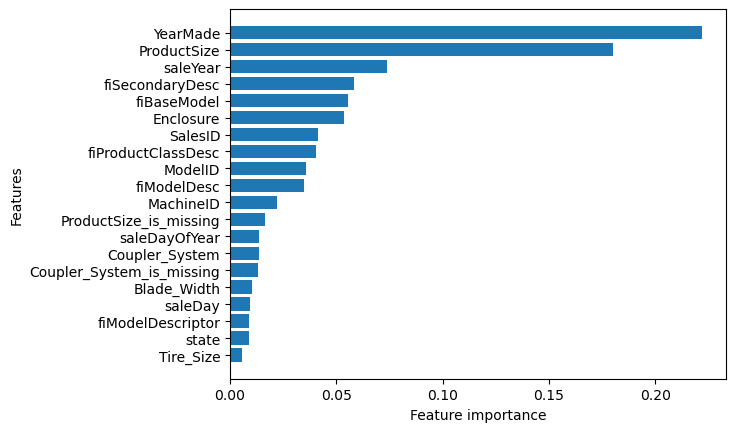

In [124]:
plot_feature_importance(X_train.columns, final_model.feature_importances_)

### Key Findings

The model identified several variables as particularly important for predicting bulldozer sale prices.

Some of the strongest predictors include:

- **YearMade** — newer machines generally have higher market prices.
- **ProductSize** — larger machines tend to be more expensive.
- **saleYear** — market conditions vary over time and affect equipment values.
- **Machine configuration features** such as `fiSecondaryDesc`, `Enclosure`, and `fiProductClassDesc` also contribute significantly to price estimation.

Interestingly, several engineered features and missing-value indicators appear among the most important variables, suggesting that both machine characteristics and data completeness contain useful predictive information.

## 6. Saving the trained model

Once the final model has been trained and evaluated, it can be exported for future use.

Saving the model allows us to load it later without retraining, which is useful for deployment, batch predictions, and integration into applications.

In [119]:
import joblib

# Export trained model
joblib.dump(final_model, "models/bulldozer-price-predictor.joblib")

['models/bulldozer-price-predictor.joblib']

In [121]:
# Load model back from disk
loaded_model = joblib.load("models/bulldozer-price-predictor.joblib")

loaded_model.score(X_valid, y_valid)

0.8809538186795809

The loaded model returns the same validation score, confirming that the serialized model artifact can be reused without retraining.

# Conclusions

In this project, a Random Forest Regressor was trained to predict bulldozer sale prices using historical auction data.

Key outcomes:

- Performed exploratory data analysis and feature engineering.
- Handled missing values and categorical variables.
- Compared baseline and tuned models.
- Optimized hyperparameters using RandomizedSearchCV.
- Generated predictions for unseen test data.
- Identified the most influential features affecting sale price.
- Trained model exported using Joblib for future inference
  
Results summary:
- Validation RMSLE: ~0.248
- Validation R²: ~0.88
- Kaggle Public Leaderboard RMSLE: 0.24012
- Model: Random Forest Regressor
- Dataset size: 412,698 training examples
- Features after preprocessing: 103